In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("./bengaluru_house_prices.csv")  #import data

In [3]:
df.head() # data points

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.shape  # shape of the data 

(13320, 9)

In [5]:
df.groupby('area_type')['area_type'].agg('count')  # gorouped the data by the area type to see the count for each areatype

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

In [6]:
df.area_type.value_counts()

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [7]:
df.drop(columns=["availability",'area_type','society','balcony',],inplace=True)  # availability and the society are not import columns to see the price prediction

In [8]:
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [9]:
df.isna().sum()  # checking the null values int he data

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.isna().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [12]:
df.shape

(13246, 5)

In [13]:
df.bath.unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9.,  8.,  7., 11., 10., 14., 27.,
       12., 16., 40., 15., 13., 18.])

In [14]:
df.bath.value_counts(normalize=True,dropna=False)

bath
2.0     0.521516
3.0     0.247999
4.0     0.092556
1.0     0.059490
5.0     0.039559
6.0     0.020610
7.0     0.007700
8.0     0.004832
9.0     0.003246
10.0    0.000981
12.0    0.000528
11.0    0.000226
13.0    0.000226
16.0    0.000151
27.0    0.000075
14.0    0.000075
40.0    0.000075
15.0    0.000075
18.0    0.000075
Name: proportion, dtype: float64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  object 
 2   total_sqft  13246 non-null  object 
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
dtypes: float64(2), object(3)
memory usage: 620.9+ KB


In [16]:
df.bath=df.bath.astype(int)

In [17]:
 df["BHK"]=df["size"].apply(lambda x : int(x.split()[0]))

In [18]:
df.tail()

,location,size,total_sqft,bath,price,BHK
13315,Whitefield,5 Bedroom,3453,4,231.0,5
13316,Richards Town,4 BHK,3600,5,400.0,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.0,2
13318,Padmanabhanagar,4 BHK,4689,4,488.0,4
13319,Doddathoguru,1 BHK,550,1,17.0,1


In [19]:
df.BHK.unique() 

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [20]:
def check(x):
    try:
        int(x)
    except:
        return True
    return False

In [21]:
df[df['total_sqft'].apply(check)]

,location,size,total_sqft,bath,price,BHK
30,Yelahanka,4 BHK,2100 - 2850,4,186.000,4
44,Kanakpura Road,2 BHK,1330.74,2,91.790,2
122,Hebbal,4 BHK,3067 - 8156,4,477.000,4
137,8th Phase JP Nagar,2 BHK,1042 - 1105,2,54.005,2
142,Kasavanhalli,3 BHK,1563.05,3,105.000,3
...,...,...,...,...,...,...
13059,Harlur,2 BHK,1200 - 1470,2,72.760,2
13086,Sindhi Colony,5 BHK,5665.84,7,988.000,5
13123,9th Phase JP Nagar,2 BHK,1331.95,2,69.000,2
13265,Hoodi,2 BHK,1133 - 1384,2,59.135,2


In [22]:
df.total_sqft.unique()[1000:2000]

array(['1392', '1675', '792', '1248', '1147', '1527', '1332', '933',
       '461.82', '2392', '989', '1199', '1149', '2180', '1818', '2430',
       '2820', '4772', '3960', '5600', '1553', '5400', '794', '4051',
       '1351', '2249.81 - 4112.19', '8321', '1777', '1576', '648', '2721',
       '2265', '2220', '1070 - 1315', '1888', '1559', '905', '829',
       '3040Sq. Meter', '2409', '3640', '1749', '1127', '4190', '1247',
       '420', '1672', '500Sq. Yards', '1817', '2043', '2779', '1224',
       '1517', '1086', '1588', '1020.07', '5965', '2806 - 3019',
       '613 - 648', '3537', '615', '956', '1218', '2559', '2363', '3895',
       '885', '1451.5', '3016', '1336', '673', '1719', '664', '1011',
       '704 - 730', '1231', '2024', '2408', '2240', '1584.01', '685',
       '1858', '3530', '3436', '1335', '1999', '3950', '1205.47', '923',
       '3595', '944', '832', '3259', '1457', '858', '1689.28', '1241',
       '2340', '596', '10000', '3126', '1318', '4428', '2912', '1301',
       '18

In [23]:
import re

In [24]:
def clean_sqft(x):
    a=x.split("-")
    if len(a)==2:
        return(float(a[0])+float(a[1]))/2
    try:
        return float(x)
    except:
        return None

In [25]:
df["SQFT"]=df.total_sqft.apply(lambda x : clean_sqft(x))

In [26]:
df.SQFT.dtype

dtype('float64')

In [27]:
df.SQFT.isna().sum()

np.int64(46)

In [28]:
df.dropna(inplace=True)

In [29]:
df.shape

(13200, 7)

In [30]:
df.loc[30]

location        Yelahanka
size                4 BHK
total_sqft    2100 - 2850
bath                    4
price               186.0
BHK                     4
SQFT               2475.0
Name: 30, dtype: object

In [31]:
df

,location,size,total_sqft,bath,price,BHK,SQFT
0,Electronic City Phase II,2 BHK,1056,2,39.07,2,1056.0
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4,2600.0
2,Uttarahalli,3 BHK,1440,2,62.00,3,1440.0
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3,1521.0
4,Kothanur,2 BHK,1200,2,51.00,2,1200.0
...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4,231.00,5,3453.0
13316,Richards Town,4 BHK,3600,5,400.00,4,3600.0
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2,1141.0
13318,Padmanabhanagar,4 BHK,4689,4,488.00,4,4689.0


In [32]:
df["per_SQFT"]=df.apply(lambda x:round((x.price/x.SQFT)*100000,2),axis=1)

In [33]:
df.per_SQFT

0         3699.81
1         4615.38
2         4305.56
3         6245.89
4         4250.00
           ...   
13315     6689.83
13316    11111.11
13317     5258.55
13318    10407.34
13319     3090.91
Name: per_SQFT, Length: 13200, dtype: float64

In [34]:
df.head()

,location,size,total_sqft,bath,price,BHK,SQFT,per_SQFT
0,Electronic City Phase II,2 BHK,1056,2,39.07,2,1056.0,3699.81
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4,2600.0,4615.38
2,Uttarahalli,3 BHK,1440,2,62.00,3,1440.0,4305.56
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3,1521.0,6245.89
4,Kothanur,2 BHK,1200,2,51.00,2,1200.0,4250.00


In [35]:
df.per_SQFT.describe()

count    1.320000e+04
mean     7.920759e+03
std      1.067272e+05
min      2.678300e+02
25%      4.267700e+03
50%      5.438335e+03
75%      7.317070e+03
max      1.200000e+07
Name: per_SQFT, dtype: float64

In [36]:
df.location.unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], dtype=object)

In [37]:
len(df.location.unique())

1298

In [38]:
df.location.value_counts()

location
Whitefield                       532
Sarjapur  Road                   392
Electronic City                  302
Kanakpura Road                   264
Thanisandra                      232
                                ... 
Gubbi Cross, Hennur Main Road      1
Sabari Nagar                       1
Ashraya Layout                     1
Whitefield ECC Road                1
Maruthi nagar kogilu               1
Name: count, Length: 1298, dtype: int64

In [39]:
location=df.groupby('location')['location'].agg('count').sort_values(ascending=False)
location.head()

location
Whitefield         532
Sarjapur  Road     392
Electronic City    302
Kanakpura Road     264
Thanisandra        232
Name: location, dtype: int64

In [40]:
len(location[location>10])

240

In [41]:
location_less=location[location<10]

In [42]:
df["location"]=df.location.apply(lambda x :"other" if x in location_less else x )

In [43]:
df.location.value_counts()

location
other                    2757
Whitefield                532
Sarjapur  Road            392
Electronic City           302
Kanakpura Road            264
                         ... 
1st Block Koramangala      10
Thyagaraja Nagar           10
Gunjur Palya               10
Dodsworth Layout           10
Nagadevanahalli            10
Name: count, Length: 254, dtype: int64

In [44]:
df

,location,size,total_sqft,bath,price,BHK,SQFT,per_SQFT
0,Electronic City Phase II,2 BHK,1056,2,39.07,2,1056.0,3699.81
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4,2600.0,4615.38
2,Uttarahalli,3 BHK,1440,2,62.00,3,1440.0,4305.56
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3,1521.0,6245.89
4,Kothanur,2 BHK,1200,2,51.00,2,1200.0,4250.00
...,...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4,231.00,5,3453.0,6689.83
13316,other,4 BHK,3600,5,400.00,4,3600.0,11111.11
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2,1141.0,5258.55
13318,Padmanabhanagar,4 BHK,4689,4,488.00,4,4689.0,10407.34


In [45]:
df.SQFT[df.BHK==1]

20       600.0
24       510.0
42       600.0
43       660.0
171      450.0
         ...  
13258    877.0
13273    510.0
13291    812.0
13305    500.0
13319    550.0
Name: SQFT, Length: 640, dtype: float64

In [46]:
df

,location,size,total_sqft,bath,price,BHK,SQFT,per_SQFT
0,Electronic City Phase II,2 BHK,1056,2,39.07,2,1056.0,3699.81
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4,2600.0,4615.38
2,Uttarahalli,3 BHK,1440,2,62.00,3,1440.0,4305.56
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3,1521.0,6245.89
4,Kothanur,2 BHK,1200,2,51.00,2,1200.0,4250.00
...,...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4,231.00,5,3453.0,6689.83
13316,other,4 BHK,3600,5,400.00,4,3600.0,11111.11
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2,1141.0,5258.55
13318,Padmanabhanagar,4 BHK,4689,4,488.00,4,4689.0,10407.34


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13200 non-null  object 
 1   size        13200 non-null  object 
 2   total_sqft  13200 non-null  object 
 3   bath        13200 non-null  int64  
 4   price       13200 non-null  float64
 5   BHK         13200 non-null  int64  
 6   SQFT        13200 non-null  float64
 7   per_SQFT    13200 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 1.4+ MB


In [48]:
df = df[~(df.SQFT/df.BHK<300)]
df.shape

(12456, 8)

In [49]:
df.drop(columns=["size","total_sqft"],axis=1,inplace=True)

C:\Users\pruth\AppData\Local\Temp\ipykernel_31008\576809825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=["size","total_sqft"],axis=1,inplace=True)


In [50]:
df.per_SQFT.describe()

count     12456.000000
mean       6308.502836
std        4168.127366
min         267.830000
25%        4210.530000
50%        5294.120000
75%        6916.670000
max      176470.590000
Name: per_SQFT, dtype: float64

In [51]:
asdsad

NameError: name 'asdsad' is not defined

In [52]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.per_SQFT)
        st = np.std(subdf.per_SQFT)
        reduced_df = subdf[(subdf.per_SQFT>(m-st)) & (subdf.per_SQFT<=(m+st))]
        df_out = pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out
df = remove_pps_outliers(df)
df.shape

(10226, 6)

In [53]:
len(df.location.unique())

254

In [54]:
df

,location,bath,price,BHK,SQFT,per_SQFT
0,Devarachikkanahalli,2,44.00,3,1250.0,3520.00
1,Devarachikkanahalli,2,40.00,2,1250.0,3200.00
2,Devarachikkanahalli,2,83.00,2,1200.0,6916.67
3,Devarachikkanahalli,2,40.00,2,1170.0,3418.80
4,Devarachikkanahalli,2,65.00,3,1425.0,4561.40
...,...,...,...,...,...,...
10221,other,2,110.00,2,1353.0,8130.08
10222,other,1,26.00,1,812.0,3201.97
10223,other,2,63.93,3,1440.0,4439.58
10224,other,2,48.00,2,1075.0,4465.12


In [55]:
def plot_scatter_chart(df,location):
    bhk2 = df[(df.location==location) & (df.BHK==2)]
    bhk3 = df[(df.location==location) & (df.BHK==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.SQFT,bhk2.price,color='blue',label='2 BHK', s=50)
    plt.scatter(bhk3.SQFT,bhk3.price,marker='+', color='green',label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()
    
plot_scatter_chart(df,"Rajaji Nagar")

NameError: name 'matplotlib' is not defined

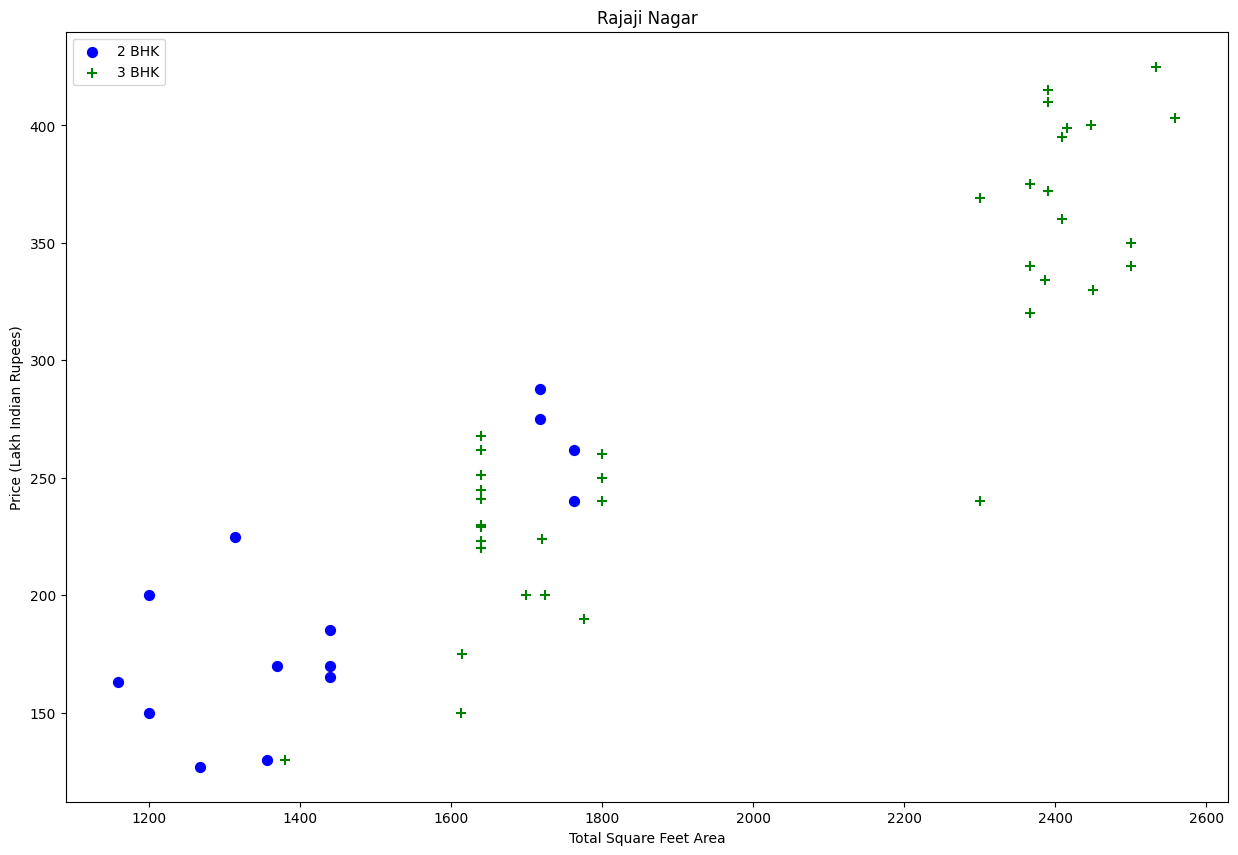

In [69]:
import matplotlib.pyplot as plt
import matplotlib
def plot_scatter_chart(df,location):
    bhk2 = df[(df.location==location) & (df.BHK==2)]
    bhk3 = df[(df.location==location) & (df.BHK==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.SQFT,bhk2.price,color='blue',label='2 BHK', s=50)
    plt.scatter(bhk3.SQFT,bhk3.price,marker='+', color='green',label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()
    
plot_scatter_chart(df,"Rajaji Nagar")

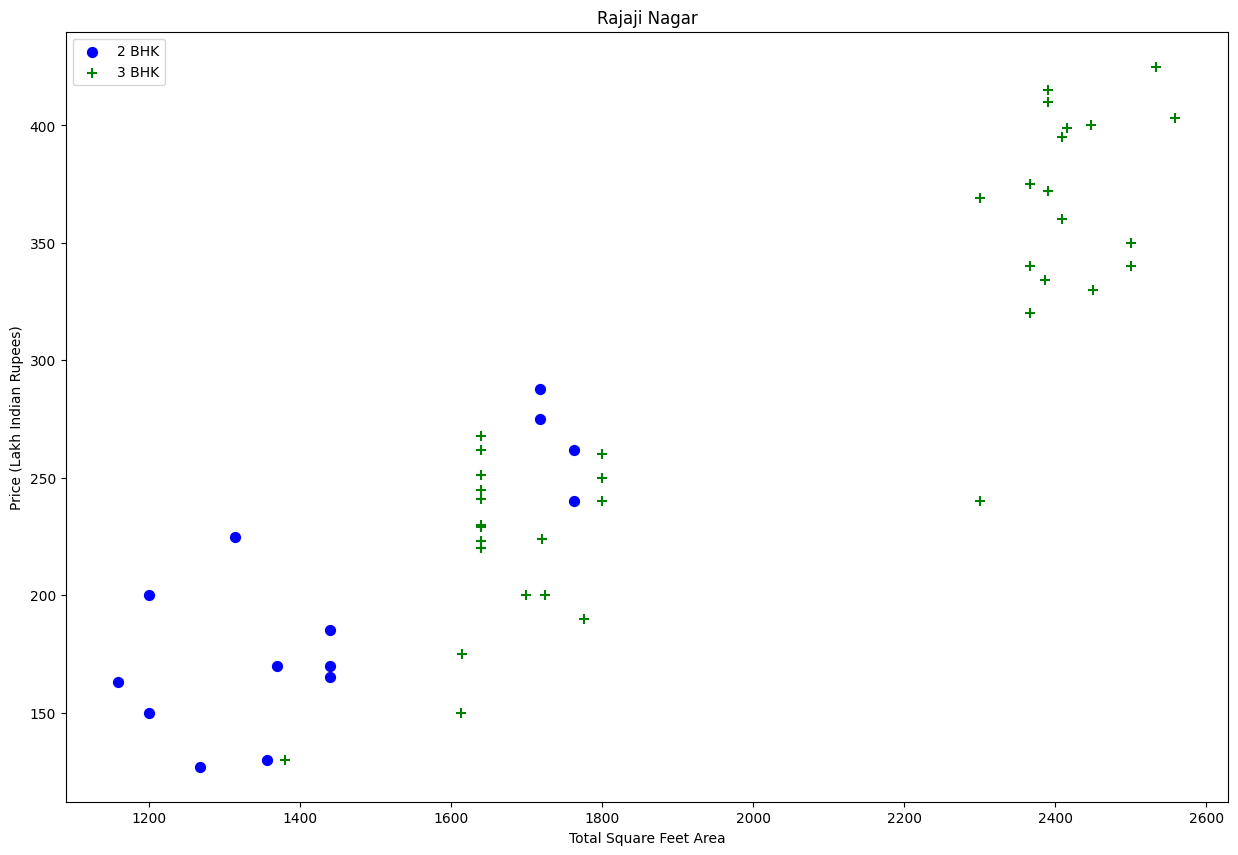

In [70]:

def plot_scatter_chart(df,location):
    bhk2 = df[(df.location==location) & (df.BHK==2)]
    bhk3 = df[(df.location==location) & (df.BHK==3)]
    matplotlib.rcParams['figure.figsize'] = (15,10)
    plt.scatter(bhk2.SQFT,bhk2.price,color='blue',label='2 BHK', s=50)
    plt.scatter(bhk3.SQFT,bhk3.price,marker='+', color='green',label='3 BHK', s=50)
    plt.xlabel("Total Square Feet Area")
    plt.ylabel("Price (Lakh Indian Rupees)")
    plt.title(location)
    plt.legend()
    
plot_scatter_chart(df,"Rajaji Nagar")

In [71]:
df[df.location =="Padmanabhanagar"].shape

(20, 6)

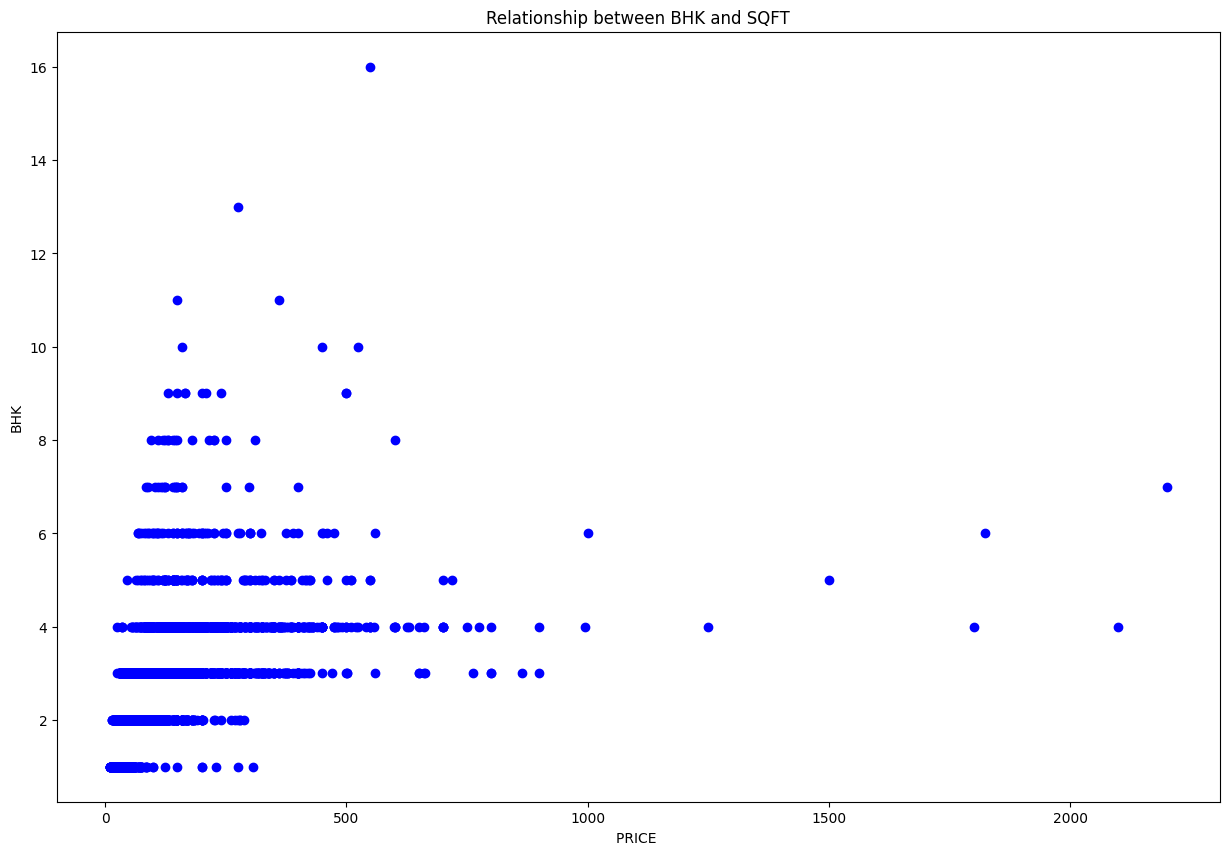

In [72]:

plt.scatter(df['price'], df['BHK'], color='blue')
plt.title('Relationship between BHK and SQFT')
plt.xlabel('PRICE ')
plt.ylabel('BHK')
plt.show()


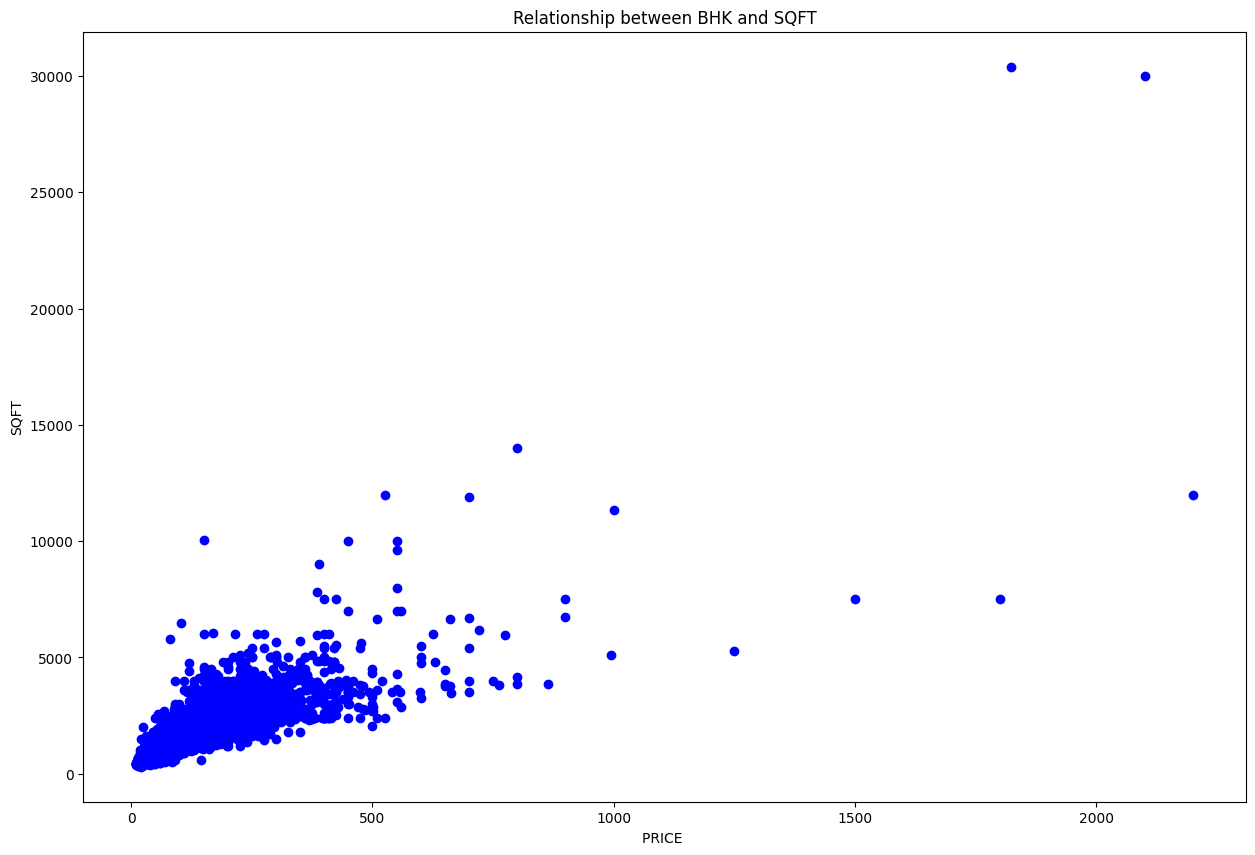

In [73]:
import matplotlib.pyplot as plt

plt.scatter(df['price'], df['SQFT'], color='blue')
plt.title('Relationship between BHK and SQFT')
plt.xlabel('PRICE ')
plt.ylabel('SQFT')
plt.show()


In [74]:
matplotlib.rcParams["figure.figsize"] = (20,10)
plt.hist(df3.per_SQFT,rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")

NameError: name 'df3' is not defined

In [57]:
df3.drop(df3[df3.bath>df3.BHK+2].index , axis=0,inplace=True)

NameError: name 'df3' is not defined

In [75]:
df3

NameError: name 'df3' is not defined

In [60]:
from sklearn.model_selection import train_test_split

In [77]:
x_train,x_test,y_train,y_test=train_test_split(df[["location","SQFT","bath","BHK"]],df.price,train_size=0.8,random_state=1)

In [78]:
from sklearn.preprocessing import OneHotEncoder

In [79]:
x_train

,location,SQFT,bath,BHK
8099,other,720.0,2,2
5829,Rajaji Nagar,2533.0,3,3
7844,Yelahanka,1792.0,3,3
6323,Sarjapur Road,994.0,2,2
8880,other,1115.0,2,2
...,...,...,...,...
2895,Hebbal,1344.0,2,2
7813,Yelahanka,1711.0,3,3
905,Bannerghatta Road,1100.0,2,3
5192,Mysore Road,1175.0,2,2


In [80]:
one=OneHotEncoder(sparse_output=False)
x_train_one=pd.DataFrame(one.fit_transform(x_train[["location"]]),columns=one.get_feature_names_out())
x_test_one=pd.DataFrame(one.transform(x_test[["location"]]),columns=one.get_feature_names_out())
x_train_one

,location_ Devarachikkanahalli,location_1st Block Jayanagar,location_1st Block Koramangala,location_1st Phase JP Nagar,location_2nd Phase Judicial Layout,location_2nd Stage Nagarbhavi,location_5th Block Hbr Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8175,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8178,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
x_train_std=pd.DataFrame(std.fit_transform(x_train[["SQFT","bath","BHK"]]),columns=std.get_feature_names_out())
x_test_std=pd.DataFrame(std.transform(x_test[["SQFT","bath","BHK"]]),columns=std.get_feature_names_out())
x_train_std

,SQFT,bath,BHK
0,-0.878546,-0.491021,-0.653888
1,1.144254,0.533609,0.473600
2,0.317506,0.533609,0.473600
3,-0.572839,-0.491021,-0.653888
4,-0.437837,-0.491021,-0.653888
...,...,...,...
8175,-0.182337,-0.491021,-0.653888
8176,0.227132,0.533609,0.473600
8177,-0.454573,-0.491021,0.473600
8178,-0.370894,-0.491021,-0.653888


In [82]:
x_train_trans=pd.concat((x_train_one,x_train_std),axis=1)
x_test_trans=pd.concat((x_test_one,x_test_std),axis=1)

In [83]:
x_train_trans

,location_ Devarachikkanahalli,location_1st Block Jayanagar,location_1st Block Koramangala,location_1st Phase JP Nagar,location_2nd Phase Judicial Layout,location_2nd Stage Nagarbhavi,location_5th Block Hbr Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,...,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other,SQFT,bath,BHK
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.878546,-0.491021,-0.653888
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.144254,0.533609,0.473600
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.317506,0.533609,0.473600
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.572839,-0.491021,-0.653888
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.437837,-0.491021,-0.653888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8175,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.182337,-0.491021,-0.653888
8176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.227132,0.533609,0.473600
8177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.454573,-0.491021,0.473600
8178,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.370894,-0.491021,-0.653888


In [84]:
from sklearn.linear_model import LinearRegression
l=LinearRegression()
l.fit(x_train_trans,y_train)

LinearRegression()

In [85]:
pre=l.predict(x_test_trans)

In [86]:
from sklearn import metrics

In [87]:
metrics.mean_squared_error(y_test,pre)

np.float64(2033.8266029023112)

In [88]:
l.score(x_test_trans,y_test)

0.7646253752765998

In [89]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
df.fit()

AttributeError: 'DataFrame' object has no attribute 'fit'

In [90]:
df3.describe(x_train_trans,y_train)
pre=dt.predict(x_test_trans)
metrics.mean_squared_error(y_test,pre)

NameError: name 'df3' is not defined